# Metody Numeryczne - Lista 1

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cProfile

Zad. 1

In [2]:
def z1(x):
    return (6 - 2*x) / (6 + 4*x + x**2)
def z2(x):
    return (6 - 4*x + x**2) / (6 + 2*x)

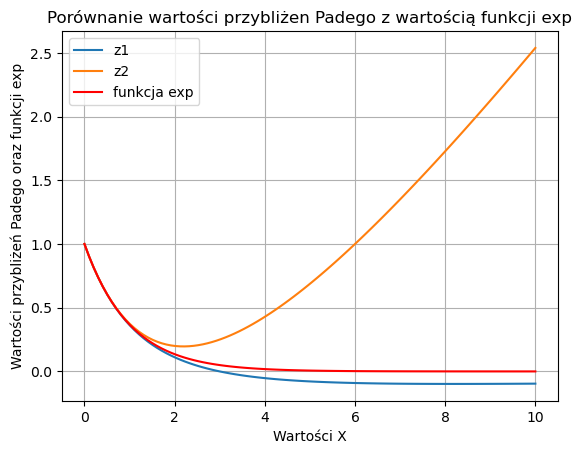

In [3]:
x_arg = np.linspace(0, 10, 100)
F = z1(x_arg)
G = z2(x_arg)
H = np.exp(-1 * x_arg)

plt.plot(x_arg, F, label='z1')
plt.plot(x_arg, G, label='z2')
plt.plot(x_arg, H, 'r', label='funkcja exp')
plt.xlabel('Wartości X')
plt.ylabel('Wartości przybliżeń Padego oraz funkcji exp')
plt.title('Porównanie wartości przybliżen Padego z wartością funkcji exp')
plt.legend()
plt.grid()
plt.show()

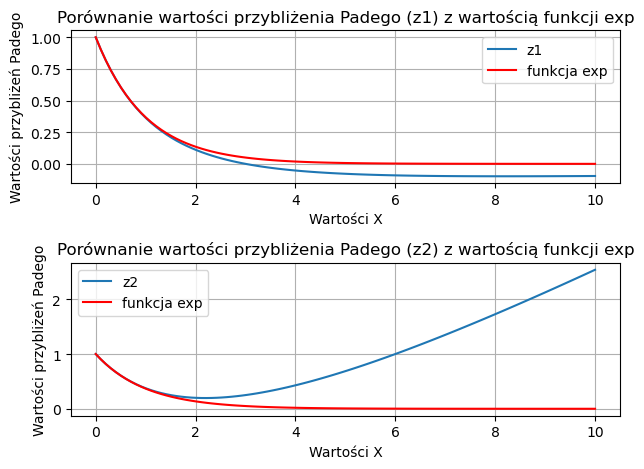

In [4]:
plt.subplot(2, 1, 1)
plt.plot(x_arg, F, label='z1')
plt.plot(x_arg, H, 'r', label='funkcja exp')
plt.xlabel('Wartości X')
plt.ylabel('Wartości przybliżeń Padego')
plt.title('Porównanie wartości przybliżenia Padego (z1) z wartością funkcji exp')
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(x_arg, G, label='z2')
plt.plot(x_arg, H, 'r', label='funkcja exp')
plt.xlabel('Wartości X')
plt.ylabel('Wartości przybliżeń Padego')
plt.title('Porównanie wartości przybliżenia Padego (z2) z wartością funkcji exp')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


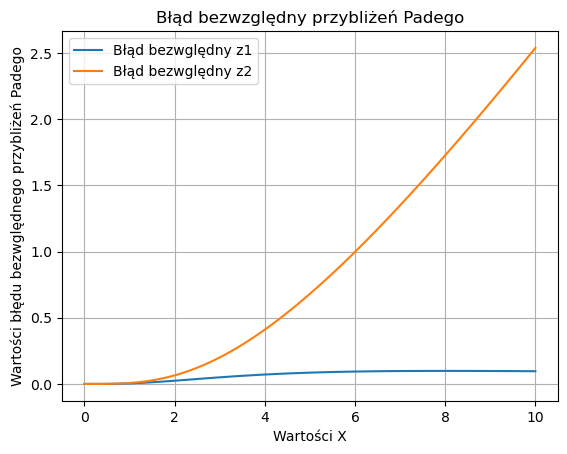

In [5]:
error_z1 = abs(F - H)
error_z2 = abs(G - H)

plt.plot(x_arg, error_z1, label='Błąd bezwględny z1')
plt.plot(x_arg, error_z2, label='Błąd bezwględny z2')
plt.title('Błąd bezwzględny przybliżeń Padego')
plt.xlabel('Wartości X')
plt.ylabel('Wartości błędu bezwględnego przybliżeń Padego')
plt.grid()
plt.legend()
plt.show()

C:\Users\lab\AppData\Local\Temp\ipykernel_13380\239152404.py:1: RuntimeWarning: invalid value encountered in divide
  relative_error_z1 = error_z1 / x_arg
C:\Users\lab\AppData\Local\Temp\ipykernel_13380\239152404.py:2: RuntimeWarning: invalid value encountered in divide
  relative_error_z2 = error_z2 / x_arg


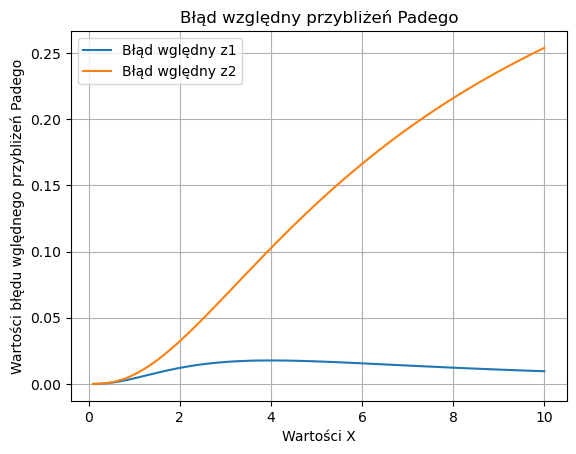

In [6]:
relative_error_z1 = error_z1 / x_arg
relative_error_z2 = error_z2 / x_arg

plt.plot(x_arg, relative_error_z1, label='Błąd wględny z1')
plt.plot(x_arg, relative_error_z2, label='Błąd wględny z2')
plt.title('Błąd względny przybliżeń Padego')
plt.xlabel('Wartości X')
plt.ylabel('Wartości błędu wględnego przybliżeń Padego')
plt.grid()
plt.legend()
plt.show()

Zad. 2

In [7]:
def machine_epsilon():
    eps = 1
    while True:
        if 1.0 + eps == 1.0:
            return eps
        else:
            eps = eps/2

print(machine_epsilon())

1.1102230246251565e-16


Zad. 3

In [8]:
x = 7 / 100 * 100 - 7
print(x)

eligible_nums = []
for num in range(1, 51):
    if num / 100 * 100 - num != 0:
        eligible_nums.append(num)

print(eligible_nums)

8.881784197001252e-16
[7, 14, 28, 29]


Zad. 4

In [9]:
def IEEE(znak, wykladnik, czesc_ulamkowa):

    return (-1)**int(znak) * 2**(int(wykladnik, 2) - 127) * (float('1.' + str(int(czesc_ulamkowa, 2))))

x = IEEE('0', '01111111', '10110011001100110011001')
print(x)

y = float('1.' + str(int('10110011001100110011001', 2)))
print(y)

1.5872025
1.5872025


In [10]:
blad_bezwgledny = abs(x - 1.7)
blad_wzgledny = blad_bezwgledny / 1.7
print('Błąd bezwzględny =', blad_bezwgledny, ', błąd względny =', blad_wzgledny)

Błąd bezwzględny = 0.11279749999999988 , błąd względny = 0.06635147058823523


Zad. 5

In [11]:
def W():
    dx = 0.0001
    x = np.arange(-10, 10+dx, dx)
    return 6 * x**4 + 5 * x**3 - 13 * x**2 + x + 1

cProfile.run('W()')

         444 function calls (432 primitive calls) in 0.019 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.001    0.001    0.001    0.001 248396555.py:1(W)
        2    0.000    0.000    0.000    0.000 <frozen abc>:121(__subclasscheck__)
        3    0.000    0.000    0.000    0.000 <frozen importlib._bootstrap>:1390(_handle_fromlist)
        1    0.000    0.000    0.001    0.001 <string>:1(<module>)
        1    0.000    0.000    0.000    0.000 asyncio.py:231(add_callback)
        3    0.000    0.000    0.000    0.000 attrsettr.py:43(__getattr__)
        3    0.000    0.000    0.000    0.000 attrsettr.py:66(_get_attr_opt)
      2/0    0.000    0.000    0.000          base_events.py:1962(_run_once)
        2    0.000    0.000    0.000    0.000 base_events.py:2060(get_debug)
        1    0.000    0.000    0.000    0.000 base_events.py:554(_check_closed)
        4    0.000    0.000    0.000    0.000 base_events

Zad. 6

In [12]:
def horner():
   
    coeffs = [6, 5, -13, 1, 1]
    dx = 0.0001
    x = np.arange(-10, 10+dx, dx)
    res = coeffs[0]
    for a in coeffs[1:]:
        res = res * x + a
    return res

cProfile.run('horner()')

         486 function calls (478 primitive calls) in 0.013 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.007    0.007    0.007    0.007 3064574761.py:1(horner)
        2    0.000    0.000    0.000    0.000 <frozen abc>:121(__subclasscheck__)
        3    0.000    0.000    0.000    0.000 <frozen importlib._bootstrap>:1390(_handle_fromlist)
        1    0.000    0.000    0.007    0.007 <string>:1(<module>)
        1    0.000    0.000    0.000    0.000 asyncio.py:231(add_callback)
        3    0.000    0.000    0.000    0.000 attrsettr.py:43(__getattr__)
        3    0.000    0.000    0.000    0.000 attrsettr.py:66(_get_attr_opt)
      1/0    0.000    0.000    0.000          base_events.py:1962(_run_once)
        2    0.000    0.000    0.000    0.000 base_events.py:2060(get_debug)
        1    0.000    0.000    0.000    0.000 base_events.py:554(_check_closed)
        2    0.000    0.000    0.000    0.000 base_